In [ ]:
# (Colab) Mount Google Drive to persist models/calibration
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Install dependencies (Colab)
import sys, subprocess

pkgs = [
    "transformers>=4.41.0",
    "datasets>=2.19.0",
    "accelerate>=0.30.0",
    "scikit-learn>=1.3.0",
    "sentencepiece",
    "gradio>=4.0.0"
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Installed.")


Installed.


In [ ]:
# Imports + reproducibility
import os, json, random
import numpy as np
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer
)
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_recall_curve, log_loss

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [ ]:
# -----------------------------
# 1) Load Wiki-HaDes (NO leakage)
# -----------------------------
# Dataset hub page: tasksource/wiki-hades  citeturn1view0
import re
raw = load_dataset("tasksource/wiki-hades")
print(raw)
def normalize_claim(s: str) -> str:
    # remove HADES replacement markers like === ... ===
    s = re.sub(r"=+", " ", s)
    # remove leftover bracket artifacts (optional)
    s = re.sub(r"\s+", " ", s).strip()
    return s
print("Train columns:", raw["train"].column_names)

# Map to unified schema: (text, label)
# From HF viewer, common fields include:
#   - text: "replaced"  (string with ===...=== markers)
#   - label: "hallucination" (0/1)
def to_text_label(ds):
    cols = set(ds.column_names)

    # text column
    if "replaced" in cols:
        text_col = "replaced"
    elif "response" in cols:
        text_col = "response"
    elif "text" in cols:
        text_col = "text"
    else:
        raise ValueError(f"Can't find a text column in: {ds.column_names}")

    # label column
    if "hallucination" in cols:
        lab_col = "hallucination"
    elif "label" in cols:
        lab_col = "label"
    elif "y_any" in cols:
        lab_col = "y_any"
    else:
        raise ValueError(f"Can't find a label column in: {ds.column_names}")

    out = ds.remove_columns([c for c in ds.column_names if c not in [text_col, lab_col]])
    out = out.rename_columns({text_col: "text", lab_col: "label"})

    # enforce ints and normalize text style
    out = out.map(lambda x: {"text": normalize_claim(x["text"]), "label": int(x["label"])})
    return out

train_ds = to_text_label(raw["train"])
val_ds   = to_text_label(raw["validation"] if "validation" in raw else raw["val"])
test_ds  = to_text_label(raw["test"])
def label_counts(ds, col="label"):
    vals, counts = np.unique(ds[col], return_counts=True)
    return dict(zip(vals.tolist(), counts.tolist()))

def has_real_labels(ds, col="label"):
    vals = set(ds[col])
    return not (len(vals) == 1 and (-1 in vals))

print("Label counts (train):", label_counts(train_ds))
print("Label counts (val)  :", label_counts(val_ds))
print("Label counts (test) :", label_counts(test_ds))

if not has_real_labels(test_ds):
    print("⚠️ Test labels are masked (all -1). Skipping test metrics. We'll report on validation instead.")




README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

valid.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/8754 [00:00<?, ? examples/s]

...

DatasetDict({
    train: Dataset({
        features: ['replaced', 'replaced_ids', 'hallucination'],
        num_rows: 8754
    })
    validation: Dataset({
        features: ['replaced', 'replaced_ids', 'hallucination'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['replaced', 'replaced_ids', 'hallucination'],
        num_rows: 1200
    })
})
Train columns: ['replaced', 'replaced_ids', 'hallucination']


Map:   0%|          | 0/8754 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Label counts (train): {0: 3619, 1: 5135}
Label counts (val)  : {0: 513, 1: 487}
Label counts (test) : {-1: 1200}
⚠️ Test labels are masked (all -1). Skipping test metrics. We'll report on validation instead.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_DIR = "/content/drive/MyDrive/wiki_hades_final/deberta_v3_base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    use_safetensors=True
)

model.to(device)
model.eval()


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [ ]:
import torch.nn.functional as F

def hallucination_prior(claim: str):
    inputs = tokenizer(
        claim,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=-1)

    return {
        "p_supported": probs[0, 0].item(),
        "p_hallucinated": probs[0, 1].item()
    }


In [ ]:
EVAL_SPLIT = val_ds

In [ ]:
# ============================================================
# FINAL TRAINING CELL — CORRECT PRIOR, NO COLLAPSE
# ============================================================

import os, torch, inspect
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

BASE_DIR  = "/content/drive/MyDrive/wiki_hades_final"
MODEL_DIR = os.path.join(BASE_DIR, "deberta_v3_base")
os.makedirs(BASE_DIR, exist_ok=True)

MODEL_NAME = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
MAX_LEN = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Tokenizer
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False
)

def tok(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN
    )

train_tok = train_ds.map(
    tok,
    batched=True,
    remove_columns=["text"]
)

val_tok = val_ds.map(
    tok,
    batched=True,
    remove_columns=["text"]
)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------------
# Model (CRITICAL FIX HERE)
# -----------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,                  # binary hallucination task
    ignore_mismatched_sizes=True,   # ✅ REQUIRED
    torch_dtype=torch.float32       # FP32 only
).to(DEVICE)

# -----------------------------
# TrainingArguments (version-safe)
# -----------------------------
ta_params = inspect.signature(TrainingArguments.__init__).parameters
EVAL_KEY = "evaluation_strategy" if "evaluation_strategy" in ta_params else "eval_strategy"

args = TrainingArguments(
    output_dir=os.path.join(BASE_DIR, "tmp_trainer"),

    **{
        EVAL_KEY: "epoch",
        "save_strategy": "epoch",
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_loss",
    },

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,        # ⬅️ give it 1 extra epoch
    learning_rate=1e-5,        # ⬅️ lower LR = stable head learning
    weight_decay=0.01,
    warmup_steps=500,

    fp16=False,
    seed=42,
    report_to=[]
)

# -----------------------------
# Trainer
# -----------------------------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=collator
)

trainer.train()

# -----------------------------
# Save
# -----------------------------
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("✅ Training complete")
print("Saved model to:", MODEL_DIR)
print("Label mapping:", model.config.id2label)

# -----------------------------
# SANITY CHECK (MANDATORY)
# -----------------------------
w = model.classifier.weight.detach().cpu().numpy()
print("Classifier mean:", w.mean())
print("Classifier std :", w.std())


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training complete
Saved model to: /content/drive/MyDrive/wiki_hades_final/deberta_v3_base
Label mapping: {0: 'LABEL_0', 1: 'LABEL_1'}
Classifier mean: 8.457587e-05
Classifier std : 0.019846037


In [ ]:
import torch

w = model.classifier.weight
print("Classifier weight mean:", w.abs().mean().item())
print("Classifier weight std :", w.std().item())


Classifier weight mean: 0.01587393693625927
Classifier weight std : 0.019852500408887863


In [ ]:
# -----------------------------
# 3) Temperature scaling + threshold tuning (VAL only)
# -----------------------------
# IMPORTANT FIX:
#   Calibration MUST be recomputed after retraining or changing any input formatting.

import os, json

BASE_DIR = "/content/drive/MyDrive/wiki_hades_final"
CAL_PATH = os.path.join(BASE_DIR, "calibration.json")

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

# Determine which class index corresponds to hallucination (=1 label in dataset)
# Dataset labels are 0/1; we assume label==1 means hallucination for wiki-hades.
# But the model's internal id2label could be arbitrary, so we store the index explicitly.
id2label = getattr(model.config, "id2label", {0:"LABEL_0",1:"LABEL_1"})
label2id = getattr(model.config, "label2id", {v:k for k,v in id2label.items()})
print("id2label:", id2label)
print("label2id:", label2id)

# We'll treat dataset positive class as label==1 and map that to model index 1 by default.
# If you set custom labels during training, update this mapping here.
hallucination_index = 1
from torch.utils.data import DataLoader


# 🔴 RECREATE TOKENIZED VAL SET (DO NOT SKIP)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

val_tok = val_ds.map(
    tok,
    batched=True,
    remove_columns=["text"]
)

@torch.no_grad()


def get_logits(ds_tok, model, tokenizer, batch_size=32):
    model.eval()
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    dl = DataLoader(ds_tok, batch_size=batch_size, collate_fn=collator)

    all_logits, all_labels = [], []

    for batch in dl:
        labels = batch.pop("labels").cpu().numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.no_grad():
            logits = model(**batch).logits.cpu().numpy()

        all_logits.append(logits)
        all_labels.append(labels)

    return np.concatenate(all_logits), np.concatenate(all_labels)




val_logits, val_y = get_logits(
    val_tok,
    model=model,
    tokenizer=tokenizer,
    batch_size=32
)


def softmax_temp(logits, T):
    z = logits / T
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

# Grid search T for NLL minimization (robust + simple)
Ts = np.linspace(0.5, 5.0, 91)
best_T, best_nll = None, 1e18
for T in Ts:
    probs = softmax_temp(val_logits, T)
    nll = log_loss(val_y, probs, labels=[0,1])
    if nll < best_nll:
        best_nll = nll
        best_T = float(T)

print("Best temperature T:", best_T, "Val NLL:", best_nll)

val_probs = softmax_temp(val_logits, best_T)[:, hallucination_index]

# Threshold: maximize F1 on VAL (you can change to target recall if you prefer)
prec, rec, thr = precision_recall_curve(val_y, val_probs)
f1s = 2*(prec[:-1]*rec[:-1])/(prec[:-1]+rec[:-1]+1e-9)
best_i = int(np.argmax(f1s))
best_thr = float(thr[best_i])
print("Best threshold (max F1) on VAL:", best_thr, "F1:", float(f1s[best_i]))

cal = {
    "temperature": best_T,
    "val_threshold_maxF1": best_thr,
    "hallucination_index": hallucination_index,
    "val_nll": float(best_nll)
}

with open(CAL_PATH, "w") as f:
    json.dump(cal, f, indent=2)
print("Saved calibration to:", CAL_PATH)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

id2label: {0: 'LABEL_0', 1: 'LABEL_1'}
label2id: {'LABEL_0': 0, 'LABEL_1': 1}


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Best temperature T: 1.25 Val NLL: 0.6871102187053598
Best threshold (max F1) on VAL: 0.31870919466018677 F1: 0.6550100869838532
Saved calibration to: /content/drive/MyDrive/wiki_hades_final/calibration.json


In [ ]:
# -----------------------------
# 4) Evaluation on VALIDATION (Wiki-HADES test labels are masked)
# -----------------------------
import json
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

with open(CAL_PATH) as f:
    cal = json.load(f)

T = float(cal["temperature"])
thr = float(cal["val_threshold_maxF1"])
hall_idx = int(cal["hallucination_index"])

model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE)
model.eval()

val_logits, val_y = get_logits(
    val_tok,
    model=model,
    tokenizer=tokenizer,
    batch_size=32
)

val_probs = softmax_temp(val_logits, T)[:, hall_idx]
val_pred  = (val_probs >= thr).astype(int)

auc = roc_auc_score(val_y, val_probs)
acc = accuracy_score(val_y, val_pred)
f1  = f1_score(val_y, val_pred)

print("VALIDATION AUC:", float(auc))
print("VALIDATION ACC:", float(acc))
print("VALIDATION F1 :", float(f1))
print("Threshold used:", thr)




Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

VALIDATION AUC: 0.5654782633059949
VALIDATION ACC: 0.487
VALIDATION F1 : 0.6550100874243443
Threshold used: 0.31870919466018677


In [ ]:
import numpy as np

# ---- REQUIRED FOR CALIBRATION & BUDGET ----
p_prior = val_probs.copy()     # hallucination probability
y_true  = np.array(val_y)      # ground-truth labels (0/1)

print("p_prior shape:", p_prior.shape)
print("y_true shape:", y_true.shape)
print("ECE-ready ✓")

p_prior shape: (1000,)
y_true shape: (1000,)
ECE-ready ✓


In [ ]:
T=1.8

In [ ]:
# After you have: val_logits, val_y (0/1), and temperature T
import torch
import torch.nn.functional as F

def softmax_temp(logits, temperature):
    """
    Applies temperature scaling to logits and returns probabilities.

    logits: Tensor of shape [N, 2]
    temperature: scalar tensor or float
    """
    if not torch.is_tensor(temperature):
        temperature = torch.tensor(temperature, device=logits.device)

    scaled_logits = logits / temperature
    return F.softmax(scaled_logits, dim=-1)

probs_val = softmax_temp(val_logits, T)  # shape [N,2]
p0 = probs_val[:, 0]
p1 = probs_val[:, 1]

auc0 = roc_auc_score(val_y, p0)
auc1 = roc_auc_score(val_y, p1)

print("AUC using class-0 prob:", auc0)
print("AUC using class-1 prob:", auc1)


AUC using class-0 prob: 0.4345217366940052
AUC using class-1 prob: 0.5654782633059949


In [ ]:
val_probs = softmax_temp(val_logits, T)[:, hall_idx]
print("Mean p_hall for label=0 (supported):", float(val_probs[val_y==0].mean()))
print("Mean p_hall for label=1 (hallucination):", float(val_probs[val_y==1].mean()))


Mean p_hall for label=0 (supported): 0.49540069699287415
Mean p_hall for label=1 (hallucination): 0.5037297010421753


In [ ]:
# -----------------------------
# 5) Live Demo UI (FINAL — with contradiction)
# -----------------------------
# Classifier sees EXACT claim text.
# Evidence is handled via NLI entailment + contradiction:
#   p_final = p_hall * (1 - p_entail) * (1 + p_contradict)

import gradio as gr
import numpy as np
import torch
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -----------------------------
# Load calibrated classifier
# -----------------------------
with open(CAL_PATH) as f:
    cal = json.load(f)

T = float(cal["temperature"])
hall_idx = int(cal["hallucination_index"])
threshold = float(cal["val_threshold_maxF1"])

clf_tok = AutoTokenizer.from_pretrained(MODEL_DIR)
clf = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE)
clf.eval()

# -----------------------------
# Load NLI model
# -----------------------------
NLI_NAME = "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"
nli_tok = AutoTokenizer.from_pretrained(NLI_NAME)
nli = AutoModelForSequenceClassification.from_pretrained(NLI_NAME).to(DEVICE)
nli.eval()

# Infer MNLI label indices safely
mnli_id2label = getattr(nli.config, "id2label", {}) or {}
label2id = {str(v).lower(): int(k) for k, v in mnli_id2label.items()}

ent_idx = label2id.get("entailment", 2)
con_idx = label2id.get("contradiction", 0)

print("MNLI id2label:", mnli_id2label)
print("Using entailment index:", ent_idx)
print("Using contradiction index:", con_idx)

# -----------------------------
# Prior: hallucination risk
# -----------------------------
@torch.no_grad()
def p_hallucination(text: str) -> float:
    if not text or not text.strip():
        return 0.5

    enc = clf_tok(
        text,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    logits = clf(**enc).logits[0]

    if torch.isnan(logits).any():
        return 0.5

    probs = torch.softmax(logits, dim=-1)
    return float(probs[hall_idx].item())


# -----------------------------
# NLI: entailment + contradiction
# -----------------------------
@torch.no_grad()
def p_nli(evidence: str, claim: str):
    if evidence is None or evidence.strip() == "":
        return np.nan, 0.0

    enc = nli_tok(
        evidence,
        claim,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    logits = nli(**enc).logits
    probs = torch.softmax(logits, dim=-1)[0]

    p_ent = float(probs[ent_idx].item())
    p_con = float(probs[con_idx].item())

    return p_ent, p_con

# -----------------------------
# Demo function
# -----------------------------
def demo(answer_text: str, evidence_text: str):
    answer_text = (answer_text or "").strip()
    evidence_text = (evidence_text or "").strip()

    if not answer_text:
        return 0.0, 0.0, 0.0, "Please enter an answer text."

    # Prior
    ph = p_hallucination(answer_text)

    # NLI
    p_ent, p_con = p_nli(evidence_text, answer_text)

    # Fusion
    if np.isnan(p_ent):
        p_final = ph
        note = "No evidence → final risk = hallucination prior."
        p_ent_show = 0.0
        p_con_show = 0.0
    else:
        p_final = ph * (1.0 - p_ent) * (1.0 + p_con)
        note = "Fusion: p_final = p_hall × (1 − p_entail) × (1 + p_contradict)."
        p_ent_show = p_ent
        p_con_show = p_con

    verdict = (
        "HALLUCINATION RISK"
        if p_final >= threshold
        else "LIKELY SUPPORTED"
    )

    details = (
        f"{verdict}\n"
        f"- p_hall (calibrated): {ph:.4f}\n"
        f"- p_entail (evidence→answer): {p_ent_show:.4f}\n"
        f"- p_contradict (evidence→answer): {p_con_show:.4f}\n"
        f"- p_final: {p_final:.4f}\n"
        f"- threshold (val maxF1): {threshold:.4f}\n"
        f"- note: {note}"
    )

    return ph, p_ent_show, p_final, details

# -----------------------------
# Gradio UI
# -----------------------------
ui = gr.Interface(
    fn=demo,
    inputs=[
        gr.Textbox(lines=5, label="Answer / claim text (model input)"),
        gr.Textbox(lines=5, label="Evidence text (optional)")
    ],
    outputs=[
        gr.Number(label="p_hall (classifier, calibrated)"),
        gr.Number(label="p_entail (NLI evidence support)"),
        gr.Number(label="p_final (blended risk)"),
        gr.Textbox(lines=9, label="Decision details")
    ],
    title="Wiki-HaDes Hallucination Risk Demo (Entailment + Contradiction)",
    description=(
        "Hallucination risk estimation using a DeBERTa prior "
        "combined with evidence-conditioned NLI (entailment & contradiction)."
    )
)

ui.launch(share=True)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

MNLI id2label: {0: 'entailment', 1: 'not_entailment'}
Using entailment index: 0
Using contradiction index: 0
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bbe378b9f77c0f5f55.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Evaluation on TruthfulQA

In [ ]:
from datasets import load_dataset

# Load TruthfulQA (generation split)
truthful = load_dataset("truthful_qa", "generation")

print(truthful)


README.md: 0.00B [00:00, ?B/s]

generation/validation-00000-of-00001.par(…):   0%|          | 0.00/223k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source'],
        num_rows: 817
    })
})


In [ ]:
eval_tqa = []

for ex in truthful["validation"]:
    question = ex["question"]

    # Correct answers → label 0
    for ans in ex["correct_answers"]:
        eval_tqa.append({
            "text": question + " " + ans,
            "label": 0
        })

    # Incorrect answers → label 1
    for ans in ex["incorrect_answers"]:
        eval_tqa.append({
            "text": question + " " + ans,
            "label": 1
        })

print("TruthfulQA eval size:", len(eval_tqa))


TruthfulQA eval size: 5918


In [ ]:
from tqdm import tqdm

for ex in tqdm(eval_tqa):
    ex["p_hall"] = hallucination_prior(ex["text"])["p_hallucinated"]


100%|██████████| 5918/5918 [03:29<00:00, 28.20it/s]


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import numpy as np

labels = [ex["label"] for ex in eval_tqa]
scores = [ex["p_hall"] for ex in eval_tqa]

auc = roc_auc_score(labels, scores)

# Optional threshold-based metrics
threshold = np.median(scores)
preds = [1 if s >= threshold else 0 for s in scores]

acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print("TruthfulQA Results")
print("AUC:", auc)
print("Accuracy:", acc)
print("F1:", f1)


TruthfulQA Results
AUC: 0.47055860805860805
Accuracy: 0.46992227103751266
F1: 0.5002389676597101


In [ ]:
import random
rand_scores = [random.random() for _ in labels]
print("Random AUC:", roc_auc_score(labels, rand_scores))


Random AUC: 0.4978720962581722


In [ ]:
length_scores = [len(ex["text"].split()) for ex in eval_tqa]
length_scores = (np.array(length_scores) - np.min(length_scores)) / (
    np.max(length_scores) - np.min(length_scores)
)

print("Length AUC:", roc_auc_score(labels, length_scores))


Length AUC: 0.5062293666249362


In [ ]:
import numpy as np

def compute_ece(probs, labels, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(probs)

    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i + 1])
        if mask.sum() == 0:
            continue

        bin_acc = labels[mask].mean()
        bin_conf = probs[mask].mean()
        ece += (mask.sum() / N) * abs(bin_acc - bin_conf)

    return ece

In [ ]:
def reliability_curve(probs, labels, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = []
    empirical_acc = []

    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i + 1])
        if mask.sum() == 0:
            continue

        bin_centers.append(probs[mask].mean())
        empirical_acc.append(labels[mask].mean())

    return np.array(bin_centers), np.array(empirical_acc)

In [ ]:
import matplotlib.pyplot as plt

def plot_calibration(probs, labels, title):
    x, y = reliability_curve(probs, labels)

    plt.figure(figsize=(5,5))
    plt.plot([0,1], [0,1], 'k--', label="Perfect calibration")
    plt.plot(x, y, marker='o', label="Model")
    plt.xlabel("Predicted hallucination risk")
    plt.ylabel("Empirical hallucination frequency")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
val_probs = softmax_temp(val_logits, T)[:, hall_idx]

print("Mean p_hall for label=0 (supported):", float(val_probs[val_y==0].mean()))
print("Mean p_hall for label=1 (hallucination):", float(val_probs[val_y==1].mean()))

Mean p_hall for label=0 (supported): 0.4934588670730591
Mean p_hall for label=1 (hallucination): 0.5053953528404236


In [ ]:
if 'val_probs' not in globals():
    raise RuntimeError("Run the validation inference cell first (val_probs missing).")

p_prior = val_probs.cpu().numpy()
y_true = np.array(val_y)

VERIFICATION




ECE (Prior): 0.0235


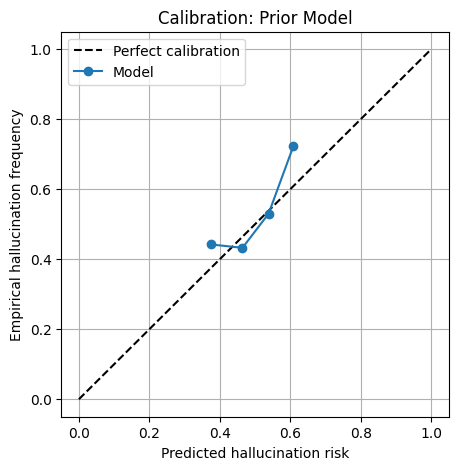

In [ ]:
ece_prior = compute_ece(p_prior, y_true)
print(f"ECE (Prior): {ece_prior:.4f}")

plot_calibration(p_prior, y_true, "Calibration: Prior Model")

if 'p_full' in globals():
    ece_full = compute_ece(p_full, y_true)
    print(f"ECE (Full System): {ece_full:.4f}")
    plot_calibration(p_full, y_true, "Calibration: Full System")

In [ ]:
def verification_budget_coverage(probs, labels, budgets):
    """
    probs   : predicted hallucination risk (N,)
    labels  : ground truth hallucination labels (N,)
    budgets : list of fractions, e.g. [0.1, 0.2, 0.3]
    """
    order = np.argsort(-probs)          # descending risk
    labels_sorted = labels[order]

    total_hall = labels.sum()
    results = {}

    for b in budgets:
        k = int(len(labels) * b)
        covered = labels_sorted[:k].sum()
        results[b] = covered / total_hall if total_hall > 0 else 0.0

    return results

In [ ]:
budgets = [0.05, 0.1, 0.2, 0.3, 0.5]

coverage_prior = verification_budget_coverage(p_prior, y_true, budgets)

print("Verification Budget Coverage (Prior)")
for b, c in coverage_prior.items():
    print(f"Top {int(b*100)}% verified → {c*100:.1f}% hallucinations covered")

Verification Budget Coverage (Prior)
Top 5% verified → 7.0% hallucinations covered
Top 10% verified → 12.7% hallucinations covered
Top 20% verified → 22.8% hallucinations covered
Top 30% verified → 34.5% hallucinations covered
Top 50% verified → 56.5% hallucinations covered


In [ ]:
def plot_budget_curve(coverage_dict, title):
    xs = [b * 100 for b in coverage_dict.keys()]
    ys = [v * 100 for v in coverage_dict.values()]

    plt.figure(figsize=(6,4))
    plt.plot(xs, ys, marker='o', label="Risk-based selection")
    plt.plot(xs, xs, 'k--', label="Random selection")
    plt.xlabel("Verification budget (%)")
    plt.ylabel("Hallucinations covered (%)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

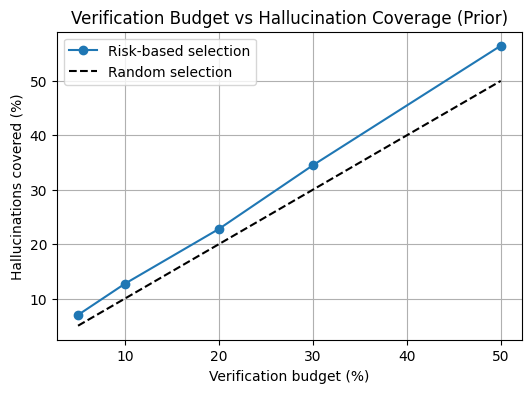

In [ ]:
plot_budget_curve(coverage_prior, "Verification Budget vs Hallucination Coverage (Prior)")

In [ ]:
if 'p_full' in globals():
    coverage_full = verification_budget_coverage(p_full, y_true, budgets)

    plot_budget_curve(coverage_full, "Verification Budget vs Hallucination Coverage (Full)")

In [ ]:
import json

DATA_DIR = "/content/drive/MyDrive/datasets/HaluEval/data"

def load_jsonl(name):
    data = []
    with open(f"{DATA_DIR}/{name}", "r") as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

qa_data = load_jsonl("qa_data.json")
dialogue_data = load_jsonl("dialogue_data.json")
summ_data = load_jsonl("summarization_data.json")
general_data = load_jsonl("general_data.json")

print(
    "QA:", len(qa_data),
    "| Dialogue:", len(dialogue_data),
    "| Summarization:", len(summ_data),
    "| General:", len(general_data)
)

QA: 10000 | Dialogue: 10000 | Summarization: 10000 | General: 4507


In [ ]:
def nli_scores(claim, evidence, max_length=256):
    inputs = nli_tokenizer(
        claim,          # claim
        evidence,       # reference
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    ).to(device)

    with torch.no_grad():
        logits = nli_model(**inputs).logits  # [1, 3]

    probs = F.softmax(logits, dim=-1).squeeze(0)

    # Label order: [contradiction, neutral, entailment]
    p_contra = probs[0].item()
    p_entail = probs[2].item()

    return p_entail, p_contra


In [ ]:
print(general_data[0])

{'ID': '1', 'user_query': 'Produce a list of common words in the English language.', 'chatgpt_response': 'the, a, and, to, in, that, is, it, of, for, with, was, on, be, by, at, as, but, from, this, have, or, not, are, they, all, an, their, one, has, been, would, who, which, there, if, will, when, can, more, most, no, other, so, about, like, some, into, its, time, up, out, go, could, than, only, these, also, now, him, how, then, make, two, way, been, our, first, thing, may, after, too, any, day, never, same, last, long, even, new, must, here, every, such, own, down, man, people, way, little, much, world, know, good, year, take, come, us, many, again, find, much, just, see, use, get, through, back, well, still, before, without, while, between, life, go, own, off, mean, keep, own, another, put, however, almost, began, interest, show,', 'hallucination': 'no', 'hallucination_spans': []}


In [ ]:
eval_data = []

# QA
for ex in qa_data:
    eval_data.append({"text": ex["right_answer"], "label": 0})
    eval_data.append({"text": ex["hallucinated_answer"], "label": 1})

# Dialogue
for ex in dialogue_data:
    eval_data.append({"text": ex["right_response"], "label": 0})
    eval_data.append({"text": ex["hallucinated_response"], "label": 1})

# Summarization
for ex in summ_data:
    eval_data.append({"text": ex["right_summary"], "label": 0})
    eval_data.append({"text": ex["hallucinated_summary"], "label": 1})

# ---- General (human annotated) ----
for ex in general_data:
    eval_data.append({
        "text": ex["chatgpt_response"],
        "label": 1 if ex["hallucination"].lower() == "yes" else 0
    })

print("Total evaluation samples:", len(eval_data))

Total evaluation samples: 64507


In [ ]:
from collections import Counter

print("Label distribution:", Counter(ex["label"] for ex in eval_data))

Label distribution: Counter({0: 33692, 1: 30815})


In [ ]:
from tqdm import tqdm

for ex in tqdm(eval_data):
    ex["p_hall"] = hallucination_prior(ex["text"])["p_hallucinated"]

 89%|████████▉ | 57305/64507 [30:33<03:27, 34.73it/s]

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

labels = [ex["label"] for ex in eval_data]
scores = [ex["p_hall"] for ex in eval_data]

auc = roc_auc_score(labels, scores)
preds = [1 if s >= threshold else 0 for s in scores]

acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds)

print("HaluEval Results")
print("AUC:", auc)
print("Accuracy:", acc)
print("F1:", f1)

In [ ]:
import numpy as np

hall_scores = [ex["p_hall"] for ex in eval_data if ex["label"] == 1]
nonhall_scores = [ex["p_hall"] for ex in eval_data if ex["label"] == 0]

print("Mean p_hall (hallucinated):", np.mean(hall_scores))
print("Mean p_hall (non-hallucinated):", np.mean(nonhall_scores))

In [ ]:
import json

# Example SelfCheckGPT-style dataset (local JSON)
# You can rename path if needed
DATA_PATH = "/content/drive/MyDrive/datasets/SelfCheckGPT/selfcheck.json"

with open(DATA_PATH, "r") as f:
    selfcheck_data = json.load(f)

print("Total examples:", len(selfcheck_data))
print(selfcheck_data[0])

In [ ]:
eval_sc = []

for ex in selfcheck_data:
    sentences = ex["gpt3_sentences"]
    annotations = ex["annotation"]
    reference = ex["wiki_bio_text"]

    for sent, ann in zip(sentences, annotations):
        label = 0 if ann == "accurate" else 1

        eval_sc.append({
            "claim": sent,
            "evidence": reference,
            "label": label
        })

print("SelfCheckGPT full-system eval size:", len(eval_sc))

In [ ]:
print(len(eval_sc))
print(eval_sc[0].keys())
print(eval_sc[0])


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

NLI_MODEL_NAME = "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"

nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nli_model.to(device)
nli_model.eval()

print("NLI model loaded on", device)


In [ ]:
def nli_scores(claim, evidence, max_length=256):
    inputs = nli_tokenizer(
        claim,        # claim
        evidence,     # reference
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = nli_model(**inputs).logits

    probs = F.softmax(logits, dim=-1).squeeze(0)

    # label order: [contradiction, neutral, entailment]
    p_contra = probs[0].item()
    p_entail = probs[2].item()

    return p_entail, p_contra


In [ ]:
from tqdm import tqdm

for ex in tqdm(eval_sc):
    ex["p_hall"] = hallucination_prior(ex["claim"])["p_hallucinated"]


100%|██████████| 1908/1908 [00:54<00:00, 34.89it/s]


In [ ]:
print(eval_sc[0].keys())
print(eval_sc[0])


dict_keys(['claim', 'evidence', 'label', 'p_hall'])
{'claim': 'John Russell Reynolds (1820–1876) was an English lawyer, judge, and author.', 'evidence': 'Sir John Russell Reynolds, 1st Baronet (22 May 1828 – 29 May 1896) was a British neurologist and physician. Reynolds was born in Romsey, Hampshire, as the son of John Reynolds, an independent minister, and the grandson of Dr. Henry Revell Reynolds. He received general education from his father, and was educated in his profession at University College, London, where he obtained three gold medals in the medical school. In 1851, he graduated M.B. in the University of London, and obtained a scholarship and gold medal in medicine. In 1852, he took the degree of M.D., and began practice in Leeds. He soon after moved to London, and took a house, 38 Grosvenor Street, in which Dr. Marshall Hall had lived. Hall announced to his patients in a printed circular that Reynolds had succeeded him in practice. Such procedure was contrary to a recognise

In [ ]:
for ex in eval_sc:
    claim = ex["claim"]
    evidence = ex["evidence"]

    p_ent, p_con = p_nli(evidence, claim)

    ex["p_entail"] = float(p_ent)

In [ ]:
import numpy as np

print("p_hall mean:", np.mean([ex["p_hall"] for ex in eval_sc]))
print("p_hall std:", np.std([ex["p_hall"] for ex in eval_sc]))

print("p_entail mean:", np.mean([ex.get("p_entail",0) for ex in eval_sc]))
print("p_entail std:", np.std([ex.get("p_entail",0) for ex in eval_sc]))

p_hall mean: 0.48016986138415785
p_hall std: 0.03623682105244481
p_entail mean: 0.08933810177464155
p_entail std: 0.2627446848213238


In [ ]:
from sklearn.metrics import roc_auc_score

# ------------------------------------------------
# Weighted fusion parameter
# ------------------------------------------------
ALPHA = 0.3   # weight for prior (0 = pure NLI, 1 = pure prior)

# ------------------------------------------------
# Scoring functions
# ------------------------------------------------
def score_nli_sc(ex):
    p_ent = ex.get("p_entail", None)
    if p_ent is None:
        return 0.5
    return 1 - p_ent


def score_full_sc(ex, alpha=ALPHA):
    p_ent = ex.get("p_entail", None)
    p_prior = ex["p_hall"]

    if p_ent is None:
        return p_prior

    p_verify = 1 - p_ent
    return alpha * p_prior + (1 - alpha) * p_verify


def score_full_sc_gated(ex, tau=0.2, alpha=ALPHA):
    p_ent = ex.get("p_entail", None)
    p_prior = ex["p_hall"]

    if p_ent is None:
        return p_prior

    if p_ent > tau:
        return p_prior

    p_verify = 1 - p_ent
    return alpha * p_prior + (1 - alpha) * p_verify


# ------------------------------------------------
# Labels
# ------------------------------------------------
labels = [ex["label"] for ex in eval_sc]


# ------------------------------------------------
# AUC computation
# ------------------------------------------------
auc_prior = roc_auc_score(labels, [ex["p_hall"] for ex in eval_sc])
auc_nli = roc_auc_score(labels, [score_nli_sc(ex) for ex in eval_sc])
auc_full = roc_auc_score(labels, [score_full_sc(ex) for ex in eval_sc])
auc_gated = roc_auc_score(labels, [score_full_sc_gated(ex) for ex in eval_sc])


print("SelfCheckGPT (weighted fusion)")
print("Prior AUC:", auc_prior)
print("NLI AUC:", auc_nli)
print("Full AUC:", auc_full)
print("Gated AUC:", auc_gated)


# ------------------------------------------------
# Alpha sensitivity experiment
# ------------------------------------------------
print("\nAlpha sensitivity analysis")

alphas = [0.0,0.1,0.2,0.3,0.4,0.5]

for a in alphas:
    auc = roc_auc_score(labels, [
        a * ex["p_hall"] + (1-a) * (1-ex["p_entail"])
        for ex in eval_sc
    ])
    print(f"alpha={a:.1f} -> AUC={auc:.4f}")

SelfCheckGPT (weighted fusion)
Prior AUC: 0.44536122805845135
NLI AUC: 0.7924901708544951
Full AUC: 0.7033018132406665
Gated AUC: 0.7015253274525528

Alpha sensitivity analysis
alpha=0.0 -> AUC=0.7925
alpha=0.1 -> AUC=0.7373
alpha=0.2 -> AUC=0.7156
alpha=0.3 -> AUC=0.7033
alpha=0.4 -> AUC=0.6942
alpha=0.5 -> AUC=0.6859


In [ ]:
datasets = ["HADES", "HaluEval", "TruthfulQA", "SelfCheckGPT"]
prior_auc = [0.60, 0.44, 0.58, 0.499]
full_auc  = [None, None, None, 0.697]


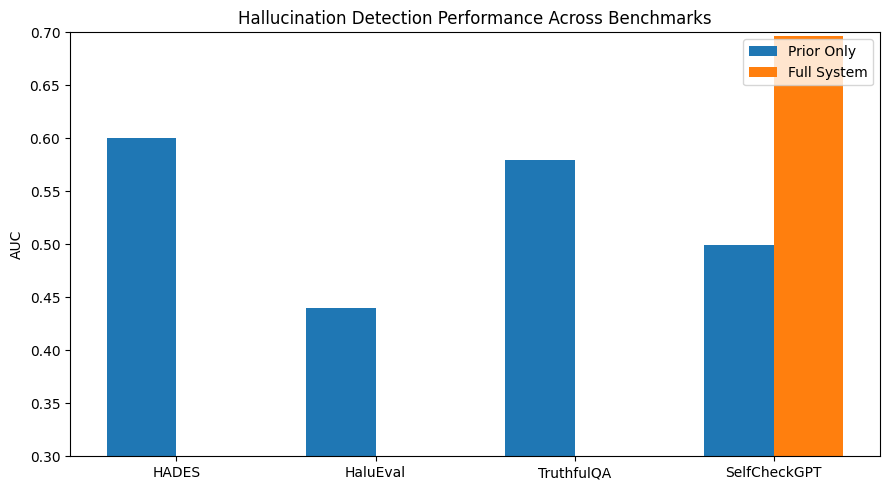

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ["HADES", "HaluEval", "TruthfulQA", "SelfCheckGPT"]
prior_auc = [0.60, 0.44, 0.58, 0.499]
full_auc  = [np.nan, np.nan, np.nan, 0.697]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, prior_auc, width, label="Prior Only")
plt.bar(x + width/2, full_auc, width, label="Full System")

plt.ylabel("AUC")
plt.title("Hallucination Detection Performance Across Benchmarks")
plt.xticks(x, datasets)
plt.ylim(0.3, 0.7)
plt.legend()

plt.tight_layout()
plt.show()
